In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt

import xobjects as xo
import xpart as xp
import xtrack as xt
import xdeps as xd

In [2]:
%matplotlib widget

In [3]:
def matchSummary(opt):
    for tt in opt._err.targets:
        if tt.line:
           nn=" ".join((tt.line,)+tt.tar)
           rr=tt.action.run()[tt.line][tt.tar]
        else:
           nn=tt.tar
           nn=" ".join(nn)
           rr=tt.action.run()[tt.tar]
        if(type(tt.value)==xt.match.LessThan):
            vv=tt.value.upper
            dd=(rr-vv)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr<(vv+tt.tol)}') 
        elif(type(tt.value)==xt.match.GreaterThan):
            vv=tt.value.lower
            dd=(rr-vv)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr>(vv-tt.tol)}')
        elif(hasattr(tt,'rhs')):
            vv=tt.rhs
            dd=(rr-vv)
            if(tt.ineq_sign=='>'):
                print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr>(vv-tt.tol)}')
            else:
                print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {rr<(vv+tt.tol)}')   
        else:
            vv=tt.value
            dd=(rr-vv)
            dd=np.abs(dd)
            print(f'{nn:25}: {rr:15.7e} {vv:15.7e} d={dd:15.7e} {dd<tt.tol}')

In [4]:
class nonlin_chroma(xd.Action):
    def __init__(self, line):
        self.line = line

    def run(self):
        deg = 7

        delta_values = np.arange(-6e-3, 7e-3, 0.5e-3)

        qx_values = delta_values * 0
        qy_values = delta_values * 0
        for i, delta in enumerate(delta_values):
            tt = self.line.twiss(delta0=delta)

            qx_values[i] = tt.qx
            qy_values[i] = tt.qy

        
        qx_fit = np.polyfit(delta_values, qx_values, deg=deg, full=False, cov=True)
        qx_coeff = qx_fit[0]

        qy_fit = np.polyfit(delta_values, qy_values, deg=deg, full=False, cov=True)
        qy_coeff = qy_fit[0]

        return {'qx0': qx_coeff[7], 'qy0': qy_coeff[7], 
                'qx1': qx_coeff[6], 'qy1': qy_coeff[6], 
                'qx2': qx_coeff[5], 'qy2': qy_coeff[5], 
                'qx3': qx_coeff[4], 'qy3': qy_coeff[4], 
                'qx4': qx_coeff[3], 'qy4': qy_coeff[3], 
                'qx5': qx_coeff[2], 'qy5': qy_coeff[2], 
                'qx6': qx_coeff[1], 'qy6': qy_coeff[1], 
                'qx7': qx_coeff[0], 'qy7': qy_coeff[0], 
               }

In [35]:
class nonlin_chroma2(xd.Action):
    def __init__(self, line, measured_tunes):
        self.line = line
        self.measured_tunes = measured_tunes

    def run(self):
        deg = 7

        delta_values = np.arange(-6e-3, 7e-3, 0.5e-3)

        qx_values = delta_values * 0
        qy_values = delta_values * 0
        for i, delta in enumerate(delta_values):
            tt = self.line.twiss(delta0=delta)

            qx_values[i] = tt.qx
            qy_values[i] = tt.qy

        
        qx_fit = np.polyfit(delta_values, qx_values, deg=deg, full=False, cov=True)
        qx_coeff = qx_fit[0]

        qy_fit = np.polyfit(delta_values, qy_values, deg=deg, full=False, cov=True)
        qy_coeff = qy_fit[0]

        qx_reduced_chi2 = np.sum((26+self.measured_tunes[1, :] - qx_values)**2) / (len(delta_values)-(deg+1))

        qy_reduced_chi2 = np.sum((26+self.measured_tunes[3, :] - qy_values)**2) / (len(delta_values)-(deg+1))

        return {'x': qx_reduced_chi2, 'y': qy_reduced_chi2}

# Load target nonlinear chromaticity values

In [5]:
chroma_data = np.loadtxt("../nonlinear_chroma_measurement_analysis/dpp_scan_fit.csv", delimiter=',')

qx0 = chroma_data[0, 0]
qx1 = chroma_data[0, 1]
qx2 = chroma_data[0, 2]
qx3 = chroma_data[0, 3]
qx4 = chroma_data[0, 4]
qx5 = chroma_data[0, 5]
qx6 = chroma_data[0, 6]
qx7 = chroma_data[0, 7]

qy0 = chroma_data[2, 0]
qy1 = chroma_data[2, 1]
qy2 = chroma_data[2, 2]
qy3 = chroma_data[2, 3]
qy4 = chroma_data[2, 4]
qy5 = chroma_data[2, 5]
qy6 = chroma_data[2, 6]
qy7 = chroma_data[2, 7]

# Load line with errors and set measurement conditions

In [6]:
line = xt.Line.from_json("sps_q26_400GeV_with_errors.json")

Loading line from dict:   0%|          | 0/45001 [00:00<?, ?it/s]

Done loading line from dict.           


In [7]:
twiss = line.twiss(continue_on_closed_orbit_error=False)

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


### Set chromaticity knobs used in the measurement

In [8]:
line.vars["qph_setvalue"] = 0.2545
line.vars["qpv_setvalue"] = 0.1932333009

# Create action for calculating nonlinear chromaticity

In [9]:
act_chroma = nonlin_chroma(line)

# Match tunes to the values obtained in measurement

In [10]:
opt_tune = line.match(solve=False,
    vary=[
        xt.VaryList(['kqf', 'kqd'], step=1e-7), 
    ],
    targets=[
        xt.TargetSet(qx=26+qx0, qy=26+qy0, tol=1e-10),
    ])
opt_tune.assert_within_tol=False
opt_tune.solve()
print(opt_tune.log())
print("Summary of matching tunes:")
matchSummary(opt_tune)

Matching: model call n. 8               

Table: 3 rows, 14 cols
iteration     penalty alpha tag tol_met target_active hit_limits vary_active    vary_0     vary_1 ...
        0    0.390387    -1     nn      yy            nn         yy          0.0146445 -0.0146214
        1  9.0533e-05     0     nn      yy            nn         yy          0.0146399 -0.0146326
        2 4.42438e-11     0     yy      yy            nn         yy          0.0146399 -0.0146326
Summary of matching tunes:
q x                      :   2.6635348e+01   2.6635348e+01 d=  2.4868996e-12 True
q y                      :   2.6576867e+01   2.6576867e+01 d=  3.6592951e-12 True


In [11]:
print("Quadrupole strengths needed to recover measured tunes:")
print("kqf =", line.vars["kqf"]._get_value())
print("kqd =", line.vars["kqd"]._get_value())

Quadrupole strengths needed to recover measured tunes:
kqf = 0.014639926489758353
kqd = -0.0146326451589069


In [13]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", 26+qx0, 26+qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
print("Q5:")
print("targets  :", qx5, qy5)
print("obtained :", test_fit["qx5"], test_fit["qy5"])
print("Q6:")
print("targets  :", qx6, qy6)
print("obtained :", test_fit["qx6"], test_fit["qy6"])
print("Q7:")
print("targets  :", qx7, qy7)
print("obtained :", test_fit["qx7"], test_fit["qy7"])

Q0:
targets  : 26.63534783433243 26.576866701090864
obtained : 26.635347832415064 26.57686670040725
Q1:
targets  : 11.915729842852382 1.5515207555838553
obtained : 6.58758052558178 4.972197555714692
Q2:
targets  : 493.163190871413 274.2451725103561
obtained : 207.76797163410913 236.0643054947641
Q3:
targets  : -61041.93369278597 163182.5846748516
obtained : 332.4890712296129 -722.889547233782
Q4:
targets  : 11890820.14762918 -4089805.5773404287
obtained : 96407.02271591361 77523.35962827013
Q5:
targets  : -2050437905.270806 -2088129474.827615
obtained : 1777630.3399187988 502382.54851873586
Q6:
targets  : -415771212687.6921 408555188488.5908
obtained : 96243821.31881104 53189920.71063603
Q7:
targets  : 78134656966730.81 63443303922552.305
obtained : 3346361844.7602434 911996815.4720355


# Match Q1 to the values obtained from fit

In [14]:
opt_q1 = line.match(solve=False,
    vary=[
        xt.VaryList(['k2_mba_err', 'k2_mbb_err'], step=1e-7), 
    ],
    targets=[
        xt.TargetSet(dqx=qx1, dqy=qy1, tol=1e-8),
    ])
opt_q1.assert_within_tol=False
opt_q1.solve()
print(opt_q1.log())
print("Summary of matching Q1:")
matchSummary(opt_q1)

Matching: model call n. 22               

Table: 5 rows, 14 cols
iteration     penalty alpha tag tol_met target_active hit_limits vary_active      vary_0 ...
        0     6.33168    -1     nn      yy            nn         yy                    0
        1 0.000522109     0     nn      yy            nn         yy          0.000151047
        2 2.00823e-08     0     ny      yy            nn         yy          0.000151068
        3 1.33843e-08     2     ny      yy            nn         yy          0.000151068
        4 4.28937e-09     4     yy      yy            nn         yy          0.000151068
Summary of matching Q1:
d q x                    :   1.1915730e+01   1.1915730e+01 d=  4.2893440e-09 True
d q y                    :   1.5515208e+00   1.5515208e+00 d=  1.4442003e-11 True


In [15]:
print("Sextupole errors on main dipoles needed to recover first order chromaticity:")
print("k2_mba_err =", line.vars["k2_mba_err"]._get_value())
print("k2_mbb_err =", line.vars["k2_mbb_err"]._get_value())

Sextupole errors on main dipoles needed to recover first order chromaticity:
k2_mba_err = 0.0001510684105879168
k2_mbb_err = 5.6732887167593374e-05


In [16]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", 26+qx0, 26+qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
print("Q5:")
print("targets  :", qx5, qy5)
print("obtained :", test_fit["qx5"], test_fit["qy5"])
print("Q6:")
print("targets  :", qx6, qy6)
print("obtained :", test_fit["qx6"], test_fit["qy6"])
print("Q7:")
print("targets  :", qx7, qy7)
print("obtained :", test_fit["qx7"], test_fit["qy7"])

Q0:
targets  : 26.63534783433243 26.576866701090864
obtained : 26.635347821538794 26.576866700500844
Q1:
targets  : 11.915729842852382 1.5515207555838553
obtained : 11.915714949207606 1.5515289124198686
Q2:
targets  : 493.163190871413 274.2451725103561
obtained : 189.20306396593801 232.95958941605025
Q3:
targets  : -61041.93369278597 163182.5846748516
obtained : 2088.424915417131 -3335.832170113951
Q4:
targets  : 11890820.14762918 -4089805.5773404287
obtained : 164566.89104314605 71610.46446507298
Q5:
targets  : -2050437905.270806 -2088129474.827615
obtained : 5835812.883345532 -1580754.3234198156
Q6:
targets  : -415771212687.6921 408555188488.5908
obtained : 346837686.3405069 49463152.67486482
Q7:
targets  : 78134656966730.81 63443303922552.305
obtained : 18800524309.34193 -1300447383.088102


# Set initial guesses for higher order errors

In [17]:
line.vars["k4_mba_err"] = 0.657859377012455
line.vars["k4_mbb_err"] = -10.861718216369024

line.vars["k5_qf_err"] = 747.9243668498927
line.vars["k5_qd_err"] = 1930.0599410102166

line.vars["k6_mba_err"] = -147176.6425580749
line.vars["k6_mbb_err"] = 846719.6052980867

line.vars["k8_mba_err"] = 13329213394.776815
line.vars["k8_mbb_err"] = -155992507663.70065

# Match Q2 to the values obtained from fit

In [ ]:
opt_q2 = line.match(solve=False,
    vary=[
        xt.VaryList(['k3_qf_err', 'k3_qd_err'], step=0.01), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx2', value=qx2, tol=(np.abs(qx2) * 0.01), tag='qx2'),
        xt.Target(action=act_chroma, tar='qy2', value=qy2, tol=(np.abs(qy2) * 0.01), tag='qy2'),
    ])
opt_q2.assert_within_tol=False
opt_q2.solve()
print(opt_q2.log())
print("Summary of matching Q2:")
matchSummary(opt_q2)

In [ ]:
print("Octupole errors on main quadrupoles needed to recover second order chromaticity:")
print("k3_qf_err =", line.vars["k3_qf_err"]._get_value())
print("k3_qd_err =", line.vars["k3_qd_err"]._get_value())

# Match Q3 to the values obtained from fit

In [18]:
opt_q3 = line.match(solve=False,
    vary=[
        xt.VaryList(['k4_mba_err', 'k4_mbb_err'], step=1e-4), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx3', value=qx3, tol=(np.abs(qx3) * 0.0001), tag='qx3'),
        xt.Target(action=act_chroma, tar='qy3', value=qy3, tol=(np.abs(qy3) * 0.0001), tag='qy3'),
    ])
opt_q3.assert_within_tol=False
opt_q3.solve()
print(opt_q3.log())
print("Summary of matching Q3:")
matchSummary(opt_q3)

Matching: model call n. 8               

Table: 3 rows, 14 cols
iteration    penalty alpha tag tol_met target_active hit_limits vary_active   vary_0   vary_1 ...
        0    12363.2    -1     nn      yy            nn         yy          0.657859 -10.8617
        1    13.7694     0     ny      yy            nn         yy          0.335811 -10.4267
        2 0.00426875     0     yy      yy            nn         yy          0.335459 -10.4263
Summary of matching Q3:
q x 3                    :  -6.1041938e+04  -6.1041934e+04 d=  4.2687520e-03 True
q y 3                    :   1.6318258e+05   1.6318258e+05 d=  2.0808657e-06 True


In [19]:
print("Decapole errors on main dipoles needed to recover third order chromaticity:")
print("k4_mba_err =", line.vars["k4_mba_err"]._get_value())
print("k4_mbb_err =", line.vars["k4_mbb_err"]._get_value())

Decapole errors on main dipoles needed to recover third order chromaticity:
k4_mba_err = 0.33545854234969263
k4_mbb_err = -10.42627553657083


In [20]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", 26+qx0, 26+qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
print("Q5:")
print("targets  :", qx5, qy5)
print("obtained :", test_fit["qx5"], test_fit["qy5"])
print("Q6:")
print("targets  :", qx6, qy6)
print("obtained :", test_fit["qx6"], test_fit["qy6"])
print("Q7:")
print("targets  :", qx7, qy7)
print("obtained :", test_fit["qx7"], test_fit["qy7"])

Q0:
targets  : 26.63534783433243 26.576866701090864
obtained : 26.635305301845968 26.57687013826726
Q1:
targets  : 11.915729842852382 1.5515207555838553
obtained : 11.875209324074689 1.549114976096992
Q2:
targets  : 493.163190871413 274.2451725103561
obtained : 223.91609008180427 229.51668227017862
Q3:
targets  : -61041.93369278597 163182.5846748516
obtained : -61041.937961537966 163182.58467277072
Q4:
targets  : 11890820.14762918 -4089805.5773404287
obtained : 7648770.460360002 -3427158.350970382
Q5:
targets  : -2050437905.270806 -2088129474.827615
obtained : -2845450774.488394 -2195109266.8257747
Q6:
targets  : -415771212687.6921 408555188488.5908
obtained : 120446593594.02444 -17069543167.759401
Q7:
targets  : 78134656966730.81 63443303922552.305
obtained : 77284958763191.88 63451040347956.44


# Match Q4 to the values obtained from fit

In [21]:
opt_q4 = line.match(solve=False,
    vary=[
        xt.VaryList(['k5_qf_err', 'k5_qd_err'], step=1e-1), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx4', value=qx4, tol=(np.abs(qx4) * 0.0001), tag='qx4'),
        xt.Target(action=act_chroma, tar='qy4', value=qy4, tol=(np.abs(qy4) * 0.0001), tag='qy4'),
    ])
opt_q4.assert_within_tol=False
opt_q4.solve()
print(opt_q4.log())
print("Summary of matching Q4:")
matchSummary(opt_q4)

Matching: model call n. 8               

Table: 3 rows, 14 cols
iteration     penalty alpha tag tol_met target_active hit_limits vary_active  vary_0  vary_1 ...
        0 4.29349e+06    -1     nn      yy            nn         yy          747.924 1930.06
        1     35423.4     0     nn      yy            nn         yy          1057.34 1666.57
        2     59.5326     0     yy      yy            nn         yy          1060.06 1655.15
Summary of matching Q4:
q x 4                    :   1.1890761e+07   1.1890820e+07 d=  5.9532590e+01 True
q y 4                    :  -4.0898056e+06  -4.0898056e+06 d=  2.2206191e-02 True


In [22]:
print("Dodecapole errors on main quadrupoles needed to recover fourth order chromaticity:")
print("k5_qf_err =", line.vars["k5_qf_err"]._get_value())
print("k5_qd_err =", line.vars["k5_qd_err"]._get_value())

Dodecapole errors on main quadrupoles needed to recover fourth order chromaticity:
k5_qf_err = 1060.0634981524368
k5_qd_err = 1655.1513529260487


In [23]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", 26+qx0, 26+qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
print("Q5:")
print("targets  :", qx5, qy5)
print("obtained :", test_fit["qx5"], test_fit["qy5"])
print("Q6:")
print("targets  :", qx6, qy6)
print("obtained :", test_fit["qx6"], test_fit["qy6"])
print("Q7:")
print("targets  :", qx7, qy7)
print("obtained :", test_fit["qx7"], test_fit["qy7"])

Q0:
targets  : 26.63534783433243 26.576866701090864
obtained : 26.63530070383009 26.57687006951861
Q1:
targets  : 11.915729842852382 1.5515207555838553
obtained : 11.867740095735835 1.5495700569078283
Q2:
targets  : 493.163190871413 274.2451725103561
obtained : 227.26223127812335 229.59908126871525
Q3:
targets  : -61041.93369278597 163182.5846748516
obtained : -58853.986057570415 163031.20535362323
Q4:
targets  : 11890820.14762918 -4089805.5773404287
obtained : 11890760.615039574 -4089805.599546619
Q5:
targets  : -2050437905.270806 -2088129474.827615
obtained : -2975878865.4983344 -2180761749.269951
Q6:
targets  : -415771212687.6921 408555188488.5908
obtained : 132529290099.5039 -16931827593.691532
Q7:
targets  : 78134656966730.81 63443303922552.305
obtained : 80784609374251.44 63053067242478.97


# Match Q5 to the values obtained from fit

In [24]:
opt_q5 = line.match(solve=False,
    vary=[
        xt.VaryList(['k6_mba_err', 'k6_mbb_err'], step=1), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx5', value=qx5, tol=(np.abs(qx5) * 0.0001), tag='qx5'),
        xt.Target(action=act_chroma, tar='qy5', value=qy5, tol=(np.abs(qy5) * 0.0001), tag='qy5'),
    ])
opt_q5.assert_within_tol=False
opt_q5.solve()
print(opt_q5.log())
print("Summary of matching Q5:")
matchSummary(opt_q5)

Matching: model call n. 16               

Table: 5 rows, 14 cols
iteration     penalty alpha tag tol_met target_active hit_limits vary_active   vary_0 vary_1 ...
        0 9.30065e+08    -1     nn      yy            nn         yy           -147177 846720
        1 1.65176e+08     0     nn      yy            nn         yy          -82477.5 671109
        2 1.40554e+07     0     ny      yy            nn         yy          -64527.8 627640
        3      489217     0     ny      yy            nn         yy          -62662.9 623123
        4     21893.5     0     yy      yy            nn         yy          -62591.6 622951
Summary of matching Q5:
q x 5                    :  -2.0504160e+09  -2.0504379e+09 d=  2.1893468e+04 True
q y 5                    :  -2.0881295e+09  -2.0881295e+09 d=  3.0366802e-01 True


In [25]:
print("Tetradecapole errors on main dipoles needed to recover fifth order chromaticity:")
print("k6_mba_err =", line.vars["k6_mba_err"]._get_value())
print("k6_mbb_err =", line.vars["k6_mbb_err"]._get_value())

Tetradecapole errors on main dipoles needed to recover fifth order chromaticity:
k6_mba_err = -62591.628289987995
k6_mbb_err = 622950.6016955969


In [26]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", 26+qx0, 26+qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
print("Q5:")
print("targets  :", qx5, qy5)
print("obtained :", test_fit["qx5"], test_fit["qy5"])
print("Q6:")
print("targets  :", qx6, qy6)
print("obtained :", test_fit["qx6"], test_fit["qy6"])
print("Q7:")
print("targets  :", qx7, qy7)
print("obtained :", test_fit["qx7"], test_fit["qy7"])

Q0:
targets  : 26.63534783433243 26.576866701090864
obtained : 26.635264111375033 26.576871255979338
Q1:
targets  : 11.915729842852382 1.5515207555838553
obtained : 11.819980732160166 1.5499921340328557
Q2:
targets  : 493.163190871413 274.2451725103561
obtained : 254.60285156212723 228.630617695258
Q3:
targets  : -61041.93369278597 163182.5846748516
obtained : -45267.29896855092 162938.04770487637
Q4:
targets  : 11890820.14762918 -4089805.5773404287
obtained : 9002598.034704844 -3975444.7006768566
Q5:
targets  : -2050437905.270806 -2088129474.827615
obtained : -2050416011.8026688 -2088129474.523947
Q6:
targets  : -415771212687.6921 408555188488.5908
obtained : 235661459850.5489 -22285792256.531498
Q7:
targets  : 78134656966730.81 63443303922552.305
obtained : 100937074604549.64 63273266828457.07


# Match Q6 to values obtained from fit

In [ ]:
# opt_q6 = line.match(solve=False,
#     vary=[
#         xt.VaryList(['k7_qf_err', 'k7_qd_err'], step=10), 
#     ],
#     targets=[
#         xt.Target(action=act_chroma, tar='qx6', value=qx6, tol=(np.abs(qx6) * 0.0001), tag='qx6'),
#         xt.Target(action=act_chroma, tar='qy6', value=qy6, tol=(np.abs(qy6) * 0.0001), tag='qy6'),
#     ])
# opt_q6.assert_within_tol=False
# opt_q6.solve()
# print(opt_q6.log())
# print("Summray of matching Q6:")
# matchSummary(opt_q6)

In [ ]:
# print("Hexadecapole errors on main quadrupoles needed to recover sixth order chromaticity:")
# print("k7_qf_err =", line.vars["k7_qf_err"]._get_value())
# print("k7_qd_err =", line.vars["k7_qd_err"]._get_value())

# Match Q7 to the values obtained from fit

In [27]:
opt_q7 = line.match(solve=False,
    vary=[
        xt.VaryList(['k8_mba_err', 'k8_mbb_err'], step=1000), 
    ],
    targets=[
        xt.Target(action=act_chroma, tar='qx7', value=qx7, tol=(np.abs(qx7) * 0.0001), tag='qx7'),
        xt.Target(action=act_chroma, tar='qy7', value=qy7, tol=(np.abs(qy7) * 0.0001), tag='qy7'),
    ])
opt_q7.assert_within_tol=False
opt_q7.solve()
print(opt_q7.log())
print("Summray of matching Q7:")
matchSummary(opt_q7)

Matching: model call n. 25               

Table: 7 rows, 14 cols
iteration     penalty alpha tag tol_met target_active hit_limits vary_active      vary_0 ...
        0 2.28031e+13    -1     nn      yy            nn         yy          1.33292e+10
        1 3.57381e+12     1     nn      yy            nn         yy           1.1397e+10
        2 5.27848e+11     0     ny      yy            nn         yy          1.17165e+10
        3 1.41059e+11     0     ny      yy            nn         yy           1.1687e+10
        4 9.16099e+10     0     ny      yy            nn         yy          1.16693e+10
        5 1.67271e+10     0     ny      yy            nn         yy           1.1675e+10
        6 7.75239e+09     0     yy      yy            nn         yy          1.16769e+10
Summray of matching Q7:
q x 7                    :   7.8142409e+13   7.8134657e+13 d=  7.7523862e+09 True
q y 7                    :   6.3443301e+13   6.3443304e+13 d=  2.8024674e+06 True


In [28]:
print("Octadecapole errors on main quadrupoles needed to recover seventh order chromaticity:")
print("k8_mba_err =", line.vars["k8_mba_err"]._get_value())
print("k8_mbb_err =", line.vars["k8_mbb_err"]._get_value())

Octadecapole errors on main quadrupoles needed to recover seventh order chromaticity:
k8_mba_err = 11676872812.364988
k8_mbb_err = -148237274329.23984


In [29]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", 26+qx0, 26+qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
print("Q5:")
print("targets  :", qx5, qy5)
print("obtained :", test_fit["qx5"], test_fit["qy5"])
print("Q6:")
print("targets  :", qx6, qy6)
print("obtained :", test_fit["qx6"], test_fit["qy6"])
print("Q7:")
print("targets  :", qx7, qy7)
print("obtained :", test_fit["qx7"], test_fit["qy7"])

Q0:
targets  : 26.63534783433243 26.576866701090864
obtained : 26.63528507570679 26.576870832044115
Q1:
targets  : 11.915729842852382 1.5515207555838553
obtained : 11.846508466015123 1.549925696210297
Q2:
targets  : 493.163190871413 274.2451725103561
obtained : 238.73773086777652 228.98575241944505
Q3:
targets  : -61041.93369278597 163182.5846748516
obtained : -52809.769822901464 162943.31305194565
Q4:
targets  : 11890820.14762918 -4089805.5773404287
obtained : 10727089.56170923 -4019078.775060282
Q5:
targets  : -2050437905.270806 -2088129474.827615
obtained : -1531115049.4951708 -2087052575.3223245
Q6:
targets  : -415771212687.6921 408555188488.5908
obtained : 184808567350.12787 -20765030156.974903
Q7:
targets  : 78134656966730.81 63443303922552.305
obtained : 78142409352914.42 63443301120084.94


# Compare to measurement

### Load measurement data

In [30]:
measured_tunes = np.loadtxt("/home/dora/Projects/PhD/data/sps_nonlin_chroma/400GeV/2024_03_05/set_1-3_processed.csv", delimiter=',')

### Compute tune curve from model

In [31]:
delta_values = np.arange(-6e-3, 6.6e-3, 0.25e-3)

qx_values = delta_values * 0
qy_values = delta_values * 0
for i, delta in enumerate(delta_values):
    tt = line.twiss(delta0=delta)

    qx_values[i] = tt.qx
    qy_values[i] = tt.qy

### Plot comparison

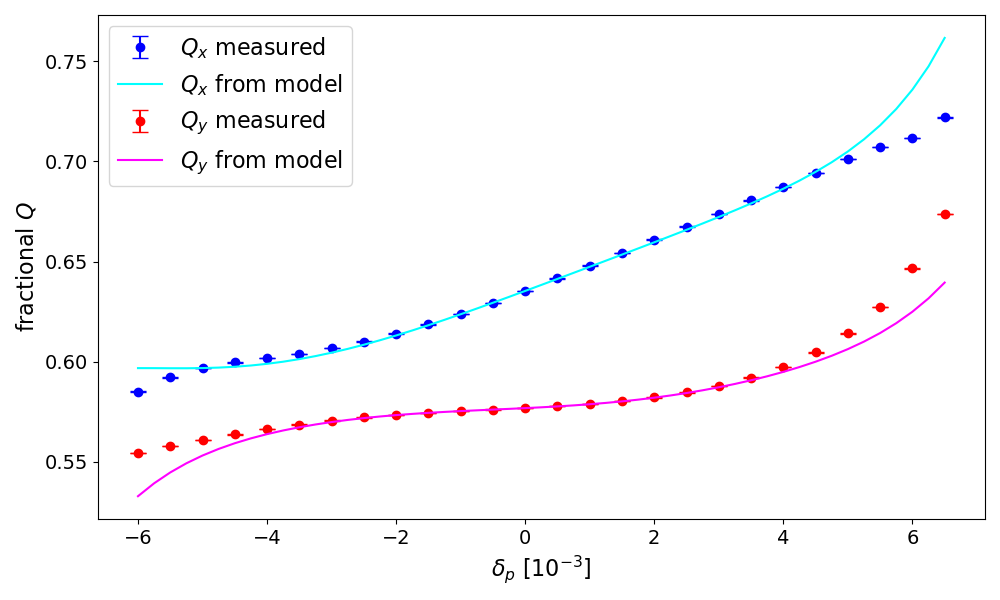

In [32]:
fs = 16
fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='tight')

ax.errorbar(measured_tunes[0, :] * 1e3, measured_tunes[1, :], measured_tunes[2, :], 
            color='blue', fmt='o', capsize=6, 
            label=r"$Q_x$ measured", zorder=1)
ax.errorbar(measured_tunes[0, :] * 1e3, measured_tunes[3, :], measured_tunes[4, :], 
            color='red', fmt='o', capsize=6, 
            label=r"$Q_y$ measured", zorder=1)
ax.plot(delta_values * 1e3, qx_values-26, 
        color='cyan', linestyle='-', 
        label=r"$Q_x$ from model", zorder=2)
ax.plot(delta_values * 1e3, qy_values-26, 
        color='magenta', linestyle='-', 
        label=r"$Q_y$ from model", zorder=2)
ax.set_xlabel(r"$\delta_p$ [$10^{-3}$]", fontsize=fs)
ax.set_ylabel(r"fractional $Q$", fontsize=fs)
ax.tick_params(axis='both', labelsize=fs-2)
handles, labels = plt.gca().get_legend_handles_labels()
order = [2, 0, 3, 1]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc=2, fontsize=fs)
plt.show()
plt.savefig("compare_model_vs_measurement_after_indiv_fit.png", dpi=300, format='png', bbox_inches='tight')

# Use higher order allowed errors and tweak other errors to get a better global fit

### Set initial guesses

In [301]:
line.vars["k9_qf_err"] = -3e12 #-4218294636465.6055 # -2.7e12
line.vars["k9_qd_err"] = -1e14 # -1693354134134849.5 # -1.5e15

line.vars["k10_mba_err"] = 2e14 # 305448716429379.5 # 2.0e14
line.vars["k10_mbb_err"] = 0.0 # 94716457896053.52 # 1e14

In [124]:
print(line.vars["k5_qf_err"]._get_value())
print(line.vars["k5_qd_err"]._get_value())

1060.0634981524368
1655.1513529260487


In [251]:
line.vars["k5_qf_err"] = line.vars["k5_qf_err"]._get_value() * 0.5
line.vars["k5_qd_err"] = line.vars["k5_qd_err"]._get_value() * -4

### Create action

In [36]:
act_glob = nonlin_chroma2(line, measured_tunes)

In [307]:
print("Other higher order errors on main dipoles and quadrupoles needed for global fit:")
print("k9_qf_err =", line.vars["k9_qf_err"]._get_value())
print("k9_qd_err =", line.vars["k9_qd_err"]._get_value())
print("k10_mba_err =", line.vars["k10_mba_err"]._get_value())
print("k10_mbb_err =", line.vars["k10_mbb_err"]._get_value())

Other higher order errors on main dipoles and quadrupoles needed for global fit:
k9_qf_err = -3000000000000.0
k9_qd_err = -100000000000000.0
k10_mba_err = 200000000000000.0
k10_mbb_err = 0.0


In [308]:
test_fit = act_chroma.run()

print("Q0:")
print("targets  :", 26+qx0, 26+qy0)
print("obtained :", test_fit["qx0"], test_fit["qy0"])
print("Q1:")
print("targets  :", qx1, qy1)
print("obtained :", test_fit["qx1"], test_fit["qy1"])
print("Q2:")
print("targets  :", qx2, qy2)
print("obtained :", test_fit["qx2"], test_fit["qy2"])
print("Q3:")
print("targets  :", qx3, qy3)
print("obtained :", test_fit["qx3"], test_fit["qy3"])
print("Q4:")
print("targets  :", qx4, qy4)
print("obtained :", test_fit["qx4"], test_fit["qy4"])
print("Q5:")
print("targets  :", qx5, qy5)
print("obtained :", test_fit["qx5"], test_fit["qy5"])
print("Q6:")
print("targets  :", qx6, qy6)
print("obtained :", test_fit["qx6"], test_fit["qy6"])
print("Q7:")
print("targets  :", qx7, qy7)
print("obtained :", test_fit["qx7"], test_fit["qy7"])

Q0:
targets  : 26.63534783433243 26.576866701090864
obtained : 26.635425397224807 26.576838300384953
Q1:
targets  : 11.915729842852382 1.5515207555838553
obtained : 11.93296847838171 1.541648835556594
Q2:
targets  : 493.163190871413 274.2451725103561
obtained : 117.69056031073825 257.9048327769754
Q3:
targets  : -61041.93369278597 163182.5846748516
obtained : -75902.78002143584 164448.73173065844
Q4:
targets  : 11890820.14762918 -4089805.5773404287
obtained : 17660586.39585435 -134591.1988575937
Q5:
targets  : -2050437905.270806 -2088129474.827615
obtained : -168871632.45904624 -2099756395.1881845
Q6:
targets  : -415771212687.6921 408555188488.5908
obtained : -482756404052.6091 153459831823.84573
Q7:
targets  : 78134656966730.81 63443303922552.305
obtained : 60470841557378.484 58108703567464.18


In [309]:
test_fit_2 = act_glob.run()

print("Reduced chi squared of fit:")
print("horizontal :", test_fit_2["x"])
print("vertical   :", test_fit_2["y"])

Reduced chi squared of fit:
horizontal : 3.907375494222822e-05
vertical   : 2.1736042625871498e-05


# Compare to measurement again

### Compute tune curve from model

In [310]:
delta_values = np.arange(-6e-3, 6.6e-3, 0.25e-3)

qx_values = delta_values * 0
qy_values = delta_values * 0
for i, delta in enumerate(delta_values):
    tt = line.twiss(delta0=delta)

    qx_values[i] = tt.qx
    qy_values[i] = tt.qy

### Plot comparison

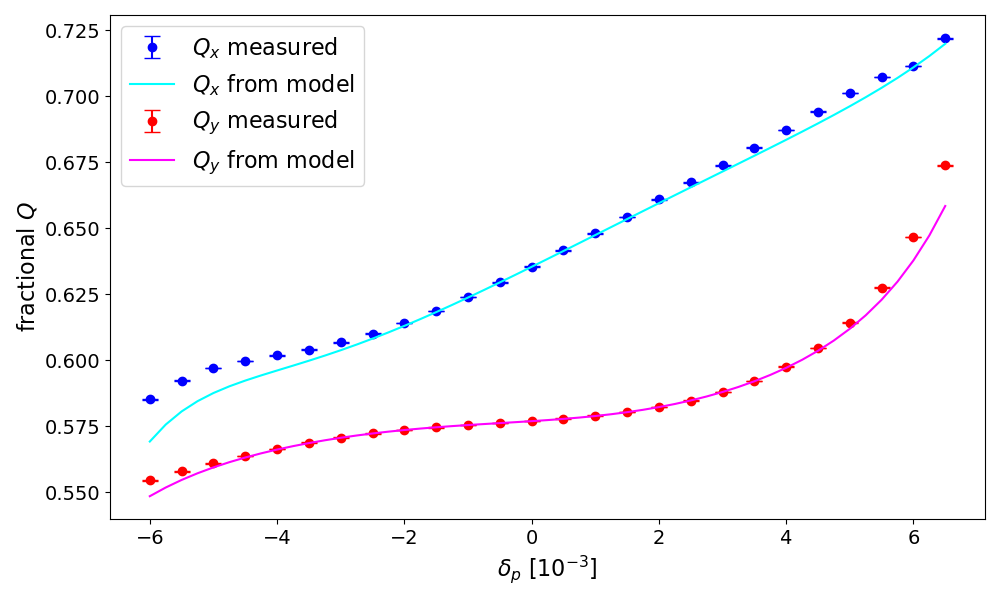

In [311]:
fs = 16
fig, ax = plt.subplots(1, 1, figsize=(10, 6), layout='tight')

ax.errorbar(measured_tunes[0, :] * 1e3, measured_tunes[1, :], measured_tunes[2, :], 
            color='blue', fmt='o', capsize=6, 
            label=r"$Q_x$ measured", zorder=1)
ax.errorbar(measured_tunes[0, :] * 1e3, measured_tunes[3, :], measured_tunes[4, :], 
            color='red', fmt='o', capsize=6, 
            label=r"$Q_y$ measured", zorder=1)
ax.plot(delta_values * 1e3, qx_values-26, 
        color='cyan', linestyle='-', 
        label=r"$Q_x$ from model", zorder=2)
ax.plot(delta_values * 1e3, qy_values-26, 
        color='magenta', linestyle='-', 
        label=r"$Q_y$ from model", zorder=2)
ax.set_xlabel(r"$\delta_p$ [$10^{-3}$]", fontsize=fs)
ax.set_ylabel(r"fractional $Q$", fontsize=fs)
ax.tick_params(axis='both', labelsize=fs-2)
handles, labels = plt.gca().get_legend_handles_labels()
order = [2, 0, 3, 1]
ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc=2, fontsize=fs)
plt.show()
plt.savefig("compare_model_vs_measurement_after_global_fit.png", dpi=300, format='png', bbox_inches='tight')

# Save errors found

In [312]:
errors = {"k2_mba": line.vars["k2_mba_err"]._get_value(), 
          "k2_mbb": line.vars["k2_mbb_err"]._get_value(), 
          "k4_mba": line.vars["k4_mba_err"]._get_value(), 
          "k4_mbb": line.vars["k4_mbb_err"]._get_value(), 
          "k5_qf": line.vars["k5_qf_err"]._get_value(), 
          "k5_qd": line.vars["k5_qd_err"]._get_value(), 
          "k6_mba": line.vars["k6_mba_err"]._get_value(), 
          "k6_mbb": line.vars["k6_mbb_err"]._get_value(), 
          "k8_mba": line.vars["k8_mba_err"]._get_value(), 
          "k8_mbb": line.vars["k8_mbb_err"]._get_value(), 
          "k9_qf": line.vars["k9_qf_err"]._get_value(), 
          "k9_qd": line.vars["k9_qd_err"]._get_value(), 
          "k10_mba": line.vars["k10_mba_err"]._get_value(), 
          "k10_mbb": line.vars["k10_mbb_err"]._get_value(), 
         }

with open("sps_400GeV_errors.json", "w") as file:
    json.dump(errors, file)

In [313]:
all_chroma = act_chroma.run()

nonlin_chroma_comparison = np.hstack((np.array([[qx0], 
                                                [qx1], 
                                                [qx2], 
                                                [qx3], 
                                                [qx4], 
                                                [qx5], 
                                                [qx6], 
                                                [qx7]]), 
                                      np.array([[all_chroma["qx0"]-26], 
                                                [all_chroma["qx1"]], 
                                                [all_chroma["qx2"]], 
                                                [all_chroma["qx3"]], 
                                                [all_chroma["qx4"]], 
                                                [all_chroma["qx5"]], 
                                                [all_chroma["qx6"]], 
                                                [all_chroma["qx7"]]]), 
                                      np.array([[(all_chroma["qx0"] - (26+qx0)) / (26+qx0) * 100], 
                                                [(all_chroma["qx1"] - qx1) / qx1 * 100], 
                                                [(all_chroma["qx2"] - qx2) / qx2 * 100], 
                                                [(all_chroma["qx3"] - qx3) / qx3 * 100], 
                                                [(all_chroma["qx4"] - qx4) / qx4 * 100], 
                                                [(all_chroma["qx5"] - qx5) / qx5 * 100], 
                                                [(all_chroma["qx6"] - qx6) / qx6 * 100], 
                                                [(all_chroma["qx7"] - qx7) / qx7 * 100]]), 
                                      np.array([[qy0], 
                                                [qy1], 
                                                [qy2], 
                                                [qy3], 
                                                [qy4], 
                                                [qy5], 
                                                [qy6], 
                                                [qy7]]), 
                                      np.array([[all_chroma["qy0"]-26], 
                                                [all_chroma["qy1"]], 
                                                [all_chroma["qy2"]], 
                                                [all_chroma["qy3"]], 
                                                [all_chroma["qy4"]], 
                                                [all_chroma["qy5"]], 
                                                [all_chroma["qy6"]], 
                                                [all_chroma["qy7"]]]), 
                                      np.array([[(all_chroma["qy0"] - (26+qy0)) / (26+qy0) * 100], 
                                                [(all_chroma["qy1"] - qy1) / qy1 * 100], 
                                                [(all_chroma["qy2"] - qy2) / qy2 * 100], 
                                                [(all_chroma["qy3"] - qy3) / qy3 * 100], 
                                                [(all_chroma["qy4"] - qy4) / qy4 * 100], 
                                                [(all_chroma["qy5"] - qy5) / qy5 * 100], 
                                                [(all_chroma["qy6"] - qy6) / qy6 * 100], 
                                                [(all_chroma["qy7"] - qy7) / qy7 * 100]])
                                     ))

np.savetxt("nonlinear_chroma_fit_vs_model_comparison.csv", nonlin_chroma_comparison, delimiter=',', 
           header="H from fit,H from model,H diff [%],V from fit,V from model,V diff [%]")

In [314]:
print("Tune:")
print("from fitting measurement:")
print("Qx0:", 26+qx0, ", Qy0:", 26+qy0)
print("from nonlinear model:")
print("Qx0:", all_chroma["qx0"], ", Qy0:", all_chroma["qy0"])
print("difference:")
print("dQx0 [%]:", (all_chroma["qx0"] - (26+qx0)) / (26+qx0) * 100, "dQy0 [%]:", (all_chroma["qy0"] - (26+qy0)) / (26+qy0) * 100)
print()
print("Q1:")
print("from fitting measurement:")
print("Qx1:", qx1, ", Qy1:", qy1)
print("from nonlinear model:")
print("Qx1:", all_chroma["qx1"], ", Qy1:", all_chroma["qy1"])
print("difference:")
print("dQx1 [%]:", (all_chroma["qx1"] - qx1) / qx1 * 100, "dQy1 [%]:", (all_chroma["qy1"] - qy1) / qy1 * 100)
print()
print("Q2:")
print("from fitting measurement:")
print("Qx2:", qx2, ", Qy2:", qy2)
print("from nonlinear model:")
print("Qx2:", all_chroma["qx2"], ", Qy2:", all_chroma["qy2"])
print("difference:")
print("dQx2 [%]:", (all_chroma["qx2"] - qx2) / qx2 * 100, "dQy2 [%]:", (all_chroma["qy2"] - qy2) / qy2 * 100)
print()
print("Q3:")
print("from fitting measurement:")
print("Qx3:", qx3, ", Qy3:", qy3)
print("from nonlinear model:")
print("Qx3:", all_chroma["qx3"], ", Qy3:", all_chroma["qy3"])
print("difference:")
print("dQx3 [%]:", (all_chroma["qx3"] - qx3) / qx3 * 100, "dQy3 [%]:", (all_chroma["qy3"] - qy3) / qy3 * 100)
print()
print("Q4:")
print("from fitting measurement:")
print("Qx4:", qx4, ", Qy4:", qy4)
print("from nonlinear model:")
print("Qx4:", all_chroma["qx4"], ", Qy4:", all_chroma["qy4"])
print("difference:")
print("dQx4 [%]:", (all_chroma["qx4"] - qx4) / qx4 * 100, "dQy4 [%]:", (all_chroma["qy4"] - qy4) / qy4 * 100)
print()
print("Q5:")
print("from fitting measurement:")
print("Qx5:", qx5, ", Qy5:", qy5)
print("from nonlinear model:")
print("Qx5:", all_chroma["qx5"], ", Qy5:", all_chroma["qy5"])
print("difference:")
print("dQx5 [%]:", (all_chroma["qx5"] - qx5) / qx5 * 100, "dQy5 [%]:", (all_chroma["qy5"] - qy5) / qy5 * 100)
print()
print("Q6:")
print("from fitting measurement:")
print("Qx6:", qx6, ", Qy6:", qy6)
print("from nonlinear model:")
print("Qx6:", all_chroma["qx6"], ", Qy6:", all_chroma["qy6"])
print("difference:")
print("dQx6 [%]:", (all_chroma["qx6"] - qx6) / qx6 * 100, "dQy6 [%]:", (all_chroma["qy6"] - qy6) / qy6 * 100)
print()
print("Q7:")
print("from fitting measurement:")
print("Qx7:", qx7, ", Qy7:", qy7)
print("from nonlinear model:")
print("Qx7:", all_chroma["qx7"], ", Qy7:", all_chroma["qy7"])
print("difference:")
print("dQx7 [%]:", (all_chroma["qx7"] - qx7) / qx7 * 100, "dQy7 [%]:", (all_chroma["qy7"] - qy7) / qy7 * 100)
print()

Tune:
from fitting measurement:
Qx0: 26.63534783433243 , Qy0: 26.576866701090864
from nonlinear model:
Qx0: 26.635425397224807 , Qy0: 26.576838300384953
difference:
dQx0 [%]: 0.00029120285141933836 dQy0 [%]: -0.0001068625065208089

Q1:
from fitting measurement:
Qx1: 11.915729842852382 , Qy1: 1.5515207555838553
from nonlinear model:
Qx1: 11.93296847838171 , Qy1: 1.541648835556594
difference:
dQx1 [%]: 0.14467125183832732 dQy1 [%]: -0.6362737972877656

Q2:
from fitting measurement:
Qx2: 493.163190871413 , Qy2: 274.2451725103561
from nonlinear model:
Qx2: 117.69056031073825 , Qy2: 257.9048327769754
difference:
dQx2 [%]: -76.13557489909566 dQy2 [%]: -5.958296214954756

Q3:
from fitting measurement:
Qx3: -61041.93369278597 , Qy3: 163182.5846748516
from nonlinear model:
Qx3: -75902.78002143584 , Qy3: 164448.73173065844
difference:
dQx3 [%]: 24.345307282436483 dQy3 [%]: 0.775908200210033

Q4:
from fitting measurement:
Qx4: 11890820.14762918 , Qy4: -4089805.5773404287
from nonlinear model:
Qx4